# MAE 6246 - Week 5 Python Example
## Stability, Discrete-Time Models, Controllability, and Observability
**Lecture:** Friday, September 25, 2026  

This notebook accompanies the Week 5 course note. It brings forward the stability experiments previously placed in Week 4, then uses a force-driven mass to connect sampling, actuation, and sensing.

**Run from the first cell.** Only NumPy, SciPy, and Matplotlib are needed, together with the standard Jupyter plotting support. No data downloads or local files are required. In Google Colab, use **Runtime > Run all**.

**Core:** Sections 1-5. **Short conceptual bridge:** Section 6. **Optional extensions:** Sections 7-8. Prediction questions appear before the relevant calculations; suggested answers are at the end.

| Question | Property |
|---|---|
| Do small initial disturbances stay small? Do they decay? | Stability |
| What state will the controller see at its next update? | Discrete-time modeling |
| Can the actuator move the plant to a desired state? | Controllability |
| Can the measurements reveal the unknown initial state? | Observability |

## Learning goals and setup

1. Distinguish stability, attraction, and transient amplification.
2. Connect exact sampled models with continuous motion under held inputs.
3. Distinguish exact discretization from Euler approximation.
4. Interpret the controllability matrix as a collection of reachable directions.
5. Interpret the observability matrix as information about the initial state.
6. Reconstruct a state from known inputs and measured outputs, and recognize the effects of noise.

Finite plots illustrate the mathematics; they do not prove a stability claim for all times and all initial conditions. Numerical rank checks below confirm simple examples whose ranks can also be established analytically.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, svdvals
from scipy.integrate import solve_ivp

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.figsize": (9, 4), "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.2,
})
SLOW, FAST, TOTAL = "#167d9a", "#d18423", "#222a42"

def exact_response(A, x0, times):
    return np.array([expm(A * t) @ x0 for t in times])

def modal_response(P, eigenvalues, coefficients, times):
    amplitudes = np.exp(times[:, None] * eigenvalues[None, :]) * coefficients
    contributions = P[None, :, :] * amplitudes[:, None, :]
    return contributions, contributions.sum(axis=2)

print("Setup complete.")

Setup complete.


## 1. Stability and transient behavior
### 1.1 Remaining nearby versus returning
- **Lyapunov stable:** for every $\varepsilon>0$, some $\delta>0$ guarantees that $\|x_0\|<\delta$ implies $\|x(t)\|<\varepsilon$ for all $t\ge0$.
- **Asymptotically stable:** stable and nearby trajectories converge to the equilibrium.
- **Exponentially stable:** $\|x(t)\|\le M e^{-\gamma t}\|x_0\|$, with $M\ge1$, $\gamma>0$.

Compare a decaying trajectory, a center, and two saddle trajectories. The saddle trajectory on the stable eigenspace converges; adding a small unstable component changes the long-term behavior. A finite simulation illustrates these definitions but cannot prove stability.

For finite-dimensional continuous-time LTI systems, attractivity in a neighborhood, asymptotic stability, and exponential stability are equivalent, and the conclusion is global. Lyapunov stability alone is weaker.

**Predict:** Which of the following trajectories converge? Can one convergent saddle trajectory prove that its equilibrium is stable?

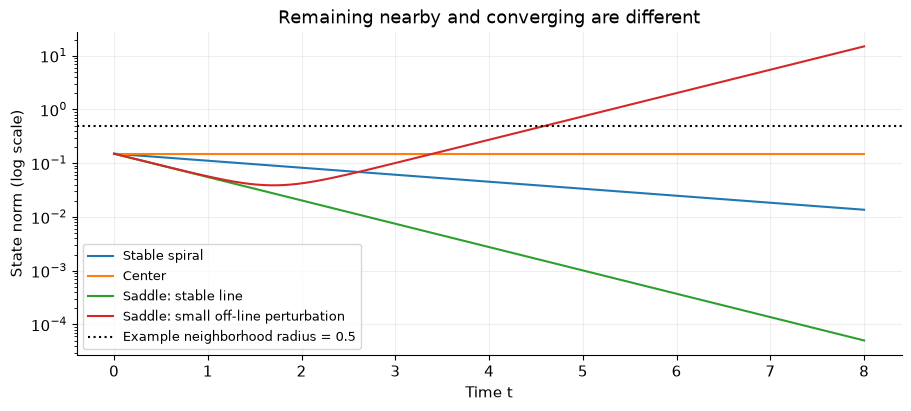

In [2]:
t_stability = np.linspace(0., 8., 801)
saddle = np.diag([-1., 1.])
stability_cases = [
    ("Stable spiral", np.array([[-.3, -1.], [1., -.3]]), np.array([.15, 0.])),
    ("Center", np.array([[0., -1.], [1., 0.]]), np.array([.15, 0.])),
    ("Saddle: stable line", saddle, np.array([.15, 0.])),
    ("Saddle: small off-line perturbation", saddle, np.array([.15, .005])),
]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
for name, A, initial in stability_cases:
    response = exact_response(A, initial, t_stability)
    ax.semilogy(t_stability, np.linalg.norm(response, axis=1), label=name)
ax.axhline(.5, color="black", ls=":", label="Example neighborhood radius = 0.5")
ax.set(xlabel="Time t", ylabel="State norm (log scale)", title="Remaining nearby and converging are different")
ax.grid(alpha=.2)
ax.legend(fontsize=9)
plt.show()

### 1.2 Why eigenvalues on the boundary need a Jordan check
For a finite-dimensional constant $A$:

- Every real part negative: asymptotically and exponentially stable.
- All real parts nonpositive, with semisimple imaginary-axis eigenvalues: Lyapunov stable.
- A positive real part, or a nontrivial imaginary-axis Jordan block: unstable.

Compare $A=0$, $J_0=\begin{bmatrix}0&1\\0&0\end{bmatrix}$, and $J_{-1}=\begin{bmatrix}-1&1\\0&-1\end{bmatrix}$. For $x_0=[0,1]^T$ their trajectories are $[0,1]^T$, $[t,1]^T$, and $e^{-t}[t,1]^T$, respectively. The first two matrices have the same eigenvalues and different stability.

All three matrices are triangular, so their eigenvalues are their diagonal entries. The zero matrix and $J_0$ illustrate why the diagonal entries alone are insufficient at the boundary. For these exact examples, use the displayed Jordan structure rather than trying to recover a Jordan form from floating-point eigenvalues.

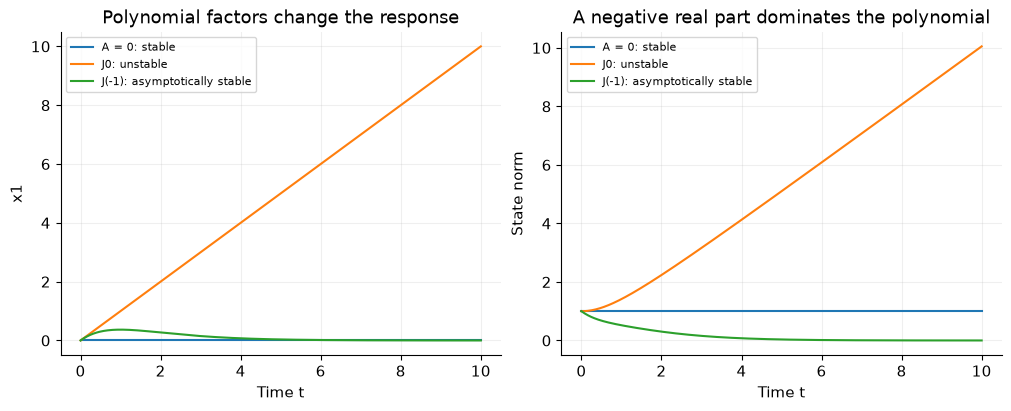

In [3]:
t_jordan = np.linspace(0., 10., 501)
x0_jordan = np.array([0., 1.])
J0 = np.array([[0., 1.], [0., 0.]])
Jminus = J0 - np.eye(2)
jordan_cases = [("A = 0: stable", np.zeros((2, 2))),
                ("J0: unstable", J0),
                ("J(-1): asymptotically stable", Jminus)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for name, A in jordan_cases:
    x = exact_response(A, x0_jordan, t_jordan)
    axes[0].plot(t_jordan, x[:, 0], label=name)
    axes[1].plot(t_jordan, np.linalg.norm(x, axis=1), label=name)
assert np.allclose(exact_response(J0, x0_jordan, t_jordan),
                   np.column_stack([t_jordan, np.ones_like(t_jordan)]))
assert np.allclose(exact_response(Jminus, x0_jordan, t_jordan),
                   np.exp(-t_jordan[:, None]) * np.column_stack([t_jordan, np.ones_like(t_jordan)]))
axes[0].set(xlabel="Time t", ylabel="x1", title="Polynomial factors change the response")
axes[1].set(xlabel="Time t", ylabel="State norm", title="A negative real part dominates the polynomial")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
plt.show()

### 1.3 Negative eigenvalues and transient growth
Reuse the non-normal example from Week 3:
$$A=\begin{bmatrix}-1&8\\0&-2\end{bmatrix},\qquad x_0=\begin{bmatrix}0\\1\end{bmatrix}.$$
With $v_1=[1,0]^T$, $v_2=[-8,1]^T$, start by expanding $x_0=8v_1+v_2$. Then
$$x(t)=8e^{-t}v_1+e^{-2t}v_2
=\begin{bmatrix}8(e^{-t}-e^{-2t})\\e^{-2t}\end{bmatrix}.$$
Initially the first components cancel. The cancellation weakens because the rates differ. At $t=\log2$, $\|x(t)\|=\sqrt{65}/4>1$. This time maximizes $x_1$, not necessarily the norm.

Compare also the normal matrix $\operatorname{diag}(-1,-2)$ from the same initial state. It has the same eigenvalues, but no temporary amplification of the Euclidean norm.

**Predict:** Does a temporary increase in the state norm contradict exponential stability?

Initial coefficients: [8. 1.]
Norm at log(2): 2.0155644370746373


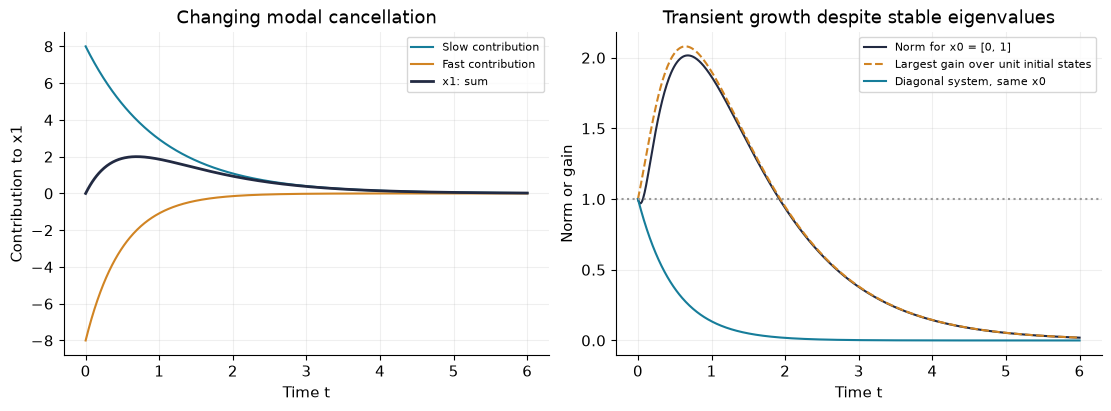

In [4]:
A_non = np.array([[-1., 8.], [0., -2.]])
P_non = np.array([[1., -8.], [0., 1.]])
x0_non = np.array([0., 1.])
c_non = np.linalg.solve(P_non, x0_non)
t_non = np.linspace(0., 6., 601)
terms_non, x_non = modal_response(P_non, np.array([-1., -2.]), c_non, t_non)
assert np.allclose(x_non, exact_response(A_non, x0_non, t_non))
state_at_log2 = expm(A_non * np.log(2)) @ x0_non
assert np.allclose(state_at_log2, [2., .25])
print("Initial coefficients:", c_non)
print("Norm at log(2):", np.linalg.norm(state_at_log2))

gain = np.array([svdvals(expm(A_non * t))[0] for t in t_non])
actual_norm = np.linalg.norm(x_non, axis=1)
normal_norm = np.linalg.norm(exact_response(np.diag([-1., -2.]), x0_non, t_non), axis=1)
assert np.all(actual_norm <= gain + 1e-12)  # initial norm is one
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(t_non, terms_non[:, 0, 0], color=SLOW, label="Slow contribution")
axes[0].plot(t_non, terms_non[:, 0, 1], color=FAST, label="Fast contribution")
axes[0].plot(t_non, x_non[:, 0], color=TOTAL, lw=2, label="x1: sum")
axes[0].set(xlabel="Time t", ylabel="Contribution to x1", title="Changing modal cancellation")
axes[1].plot(t_non, actual_norm, color=TOTAL, label="Norm for x0 = [0, 1]")
axes[1].plot(t_non, gain, "--", color=FAST, label="Largest gain over unit initial states")
axes[1].plot(t_non, normal_norm, color=SLOW, label="Diagonal system, same x0")
axes[1].axhline(1, color="0.6", ls=":")
axes[1].set(xlabel="Time t", ylabel="Norm or gain", title="Transient growth despite stable eigenvalues")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
plt.show()

## 2. Why use a discrete-time model?

A digital controller samples sensors, computes a command, and holds that command until its next update. The plant keeps moving between updates. A discrete-time model asks: **given the state now and the command held during this interval, what is the state at the next update?**

For $t_k=kh$, $x_k=x(t_k)$, and $u(t)=u_k$ on $[t_k,t_{k+1})$,
$$x_{k+1}=A_d x_k+B_d u_k,\qquad
A_d=e^{Ah},\qquad B_d=\int_0^h e^{As}B\,ds.$$
This is exact at sampling instants under a zero-order hold. It does not assume the state is constant between samples.

Our running example is a mass driven by a force:
$$m\ddot q=u,\qquad x=\begin{bmatrix}q\\v\end{bmatrix},\qquad
A=\begin{bmatrix}0&1\\0&0\end{bmatrix},\quad B=\begin{bmatrix}0\\1/m\end{bmatrix}.$$
The parameters below are in consistent units (seconds, meters, kilograms, newtons).

### 2.1 Compute the exact model without inverting $A$

The mass matrix $A$ is singular, but $e^{Ah}$ is always invertible. Use
$$\exp\!\left(h\begin{bmatrix}A&B\\0&0\end{bmatrix}\right)
=\begin{bmatrix}A_d&B_d\\0&I\end{bmatrix}.$$

For the mass, the formulas are
$$A_d=\begin{bmatrix}1&h\\0&1\end{bmatrix},\qquad
B_d=\begin{bmatrix}h^2/(2m)\\h/m\end{bmatrix}.$$
**Predict:** Why does the input affect both position and velocity during one interval, even though the first entry of $B$ is zero?

In [5]:
def zoh_discretize(A, B, h):
    """Exact zero-order-hold model, including singular A."""
    A, B = np.asarray(A, dtype=float), np.asarray(B, dtype=float)
    n, inputs = B.shape
    if A.shape != (n, n) or h <= 0:
        raise ValueError("A and B must have compatible shapes, with h > 0.")
    augmented = np.zeros((n + inputs, n + inputs))
    augmented[:n, :n], augmented[:n, n:] = A, B
    E = expm(h * augmented)
    return E[:n, :n], E[:n, n:]

mass = 1.0
h = 1.0
A_mass = np.array([[0., 1.], [0., 0.]])
B_mass = np.array([[0.], [1. / mass]])
Ad, Bd = zoh_discretize(A_mass, B_mass, h)
assert np.allclose(Ad, [[1., h], [0., 1.]])
assert np.allclose(Bd, [[h*h / (2*mass)], [h/mass]])
assert np.allclose(Ad @ expm(-h*A_mass), np.eye(2))
print("A_d =\n", Ad, "\nB_d =\n", Bd)
print("det(A) =", np.linalg.det(A_mass), "; det(A_d) =", np.linalg.det(Ad))

A_d =
 [[1. 1.]
 [0. 1.]] 
B_d =
 [[0.5]
 [1. ]]
det(A) = 0.0 ; det(A_d) = 1.0


### 2.2 Compare the recurrence with continuous motion

The discrete-time solution is
$$x_k=A_d^k x_0+\sum_{j=0}^{k-1}A_d^{k-1-j}B_d u_j.$$
Use the input sequence $[1,-1,0.5,0,-0.5,0]$ and start from rest. We compare three calculations: the recurrence, its expanded sum, and numerical integration of the continuous plant on each held-input interval.

Restarting the integrator at each command change prevents it from stepping across an input jump as if the input were smooth.

Largest sample-point difference from ODE integration: 4.00e-15


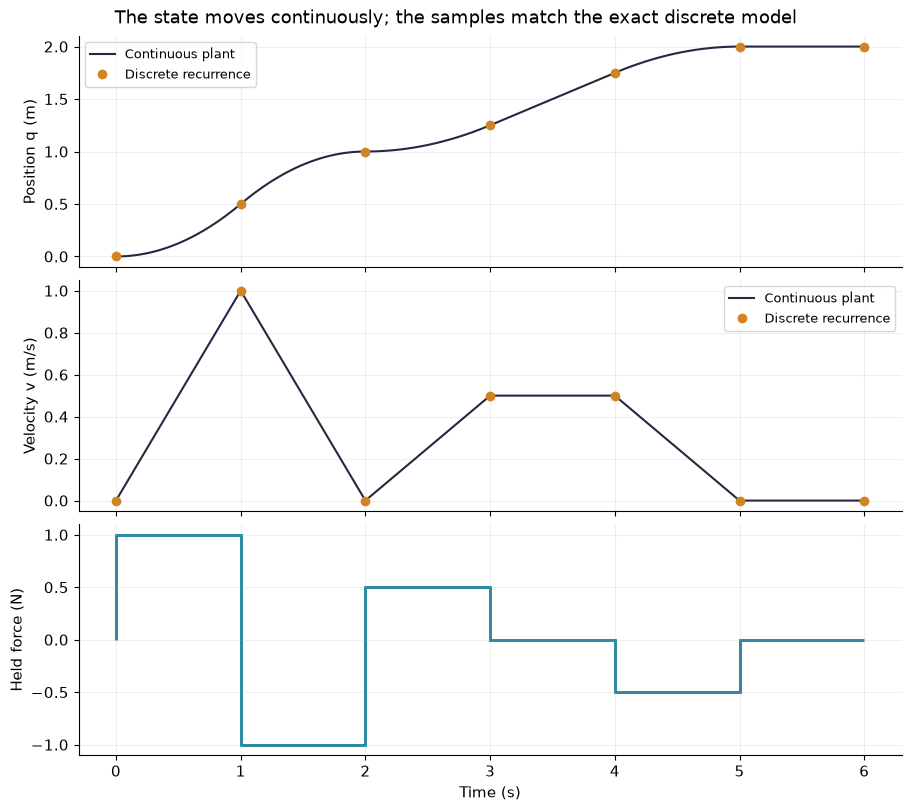

In [6]:
def simulate_discrete(A, B, inputs, x0):
    inputs = np.asarray(inputs, dtype=float)
    if inputs.ndim == 1:
        inputs = inputs[:, None]  # scalar-input sequence
    if inputs.shape[1] != B.shape[1]:
        raise ValueError("Each input must have B.shape[1] components.")
    states = np.empty((len(inputs) + 1, A.shape[0]))
    states[0] = x0
    for k, u in enumerate(inputs):
        states[k + 1] = A @ states[k] + B @ u
    return states

u_hold = np.array([1., -1., .5, 0., -.5, 0.])
x_start = np.array([0., 0.])
x_samples = simulate_discrete(Ad, Bd, u_hold, x_start)
sample_times = h * np.arange(len(u_hold) + 1)
expanded = []
for k in range(len(x_samples)):
    state = np.linalg.matrix_power(Ad, k) @ x_start
    for j in range(k):
        state += np.linalg.matrix_power(Ad, k-1-j) @ Bd[:, 0] * u_hold[j]
    expanded.append(state)
assert np.allclose(expanded, x_samples)

continuous_t, continuous_x, ode_samples = [0.], [x_start.copy()], [x_start.copy()]
state = x_start.copy()
for k, force in enumerate(u_hold):
    t0, t1 = sample_times[k:k+2]
    segment = solve_ivp(
        lambda time, x: A_mass @ x + B_mass[:, 0] * force,
        (t0, t1), state, t_eval=np.linspace(t0, t1, 51),
        rtol=1e-10, atol=1e-12,
    )
    assert segment.success
    continuous_t.extend(segment.t[1:])
    continuous_x.extend(segment.y.T[1:])
    state = segment.y[:, -1]
    ode_samples.append(state.copy())
continuous_t, continuous_x = np.array(continuous_t), np.array(continuous_x)
error = np.max(np.abs(np.array(ode_samples) - x_samples))
assert error < 1e-8
print(f"Largest sample-point difference from ODE integration: {error:.2e}")

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True, layout="constrained")
for j, label in enumerate(["Position q (m)", "Velocity v (m/s)"]):
    axes[j].plot(continuous_t, continuous_x[:, j], color=TOTAL, label="Continuous plant")
    axes[j].plot(sample_times, x_samples[:, j], "o", color=FAST, label="Discrete recurrence")
    axes[j].set(ylabel=label)
    axes[j].legend(fontsize=9)
axes[2].stairs(u_hold, sample_times, color=SLOW, linewidth=2)
axes[2].set(xlabel="Time (s)", ylabel="Held force (N)")
fig.suptitle("The state moves continuously; the samples match the exact discrete model")
plt.show()

## 3. Exact sampling versus forward Euler

For $\dot x=-2x$, exact sampling gives $x_{k+1}=e^{-2h}x_k$. Euler gives $x_{k+1}=(1-2h)x_k$.

- Exact: $|e^{-2h}|<1$ for every $h>0$.
- Euler: $|1-2h|<1$ only for $0<h<1$.

A discrete-time LTI system is asymptotically stable when every eigenvalue lies **inside the unit circle**. Boundary eigenvalues require a Jordan-structure check, as in continuous time.

**Predict:** What will the Euler approximation do for $h=1.2$? Is that behavior a property of the physical system?

h=0.2: exact multiplier=0.67032, Euler multiplier=0.60
h=0.8: exact multiplier=0.20190, Euler multiplier=-0.60
h=1.2: exact multiplier=0.09072, Euler multiplier=-1.40


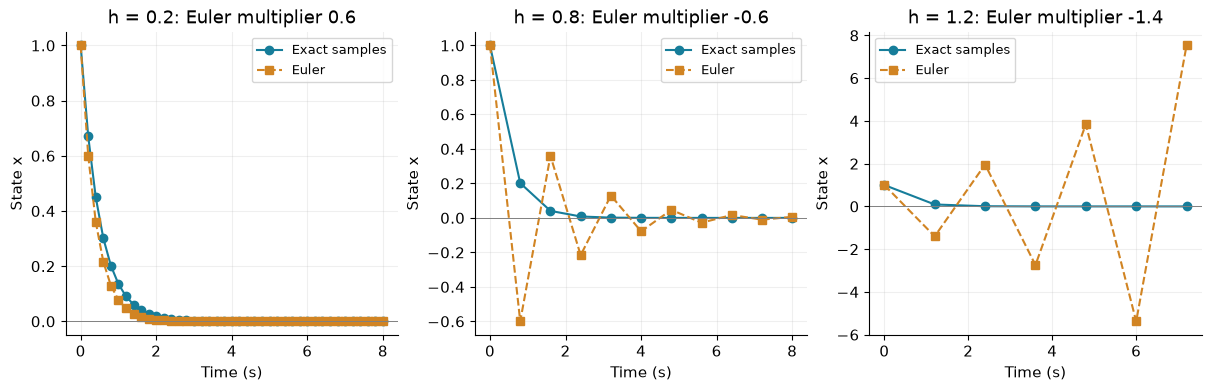

In [7]:
sample_periods = [.2, .8, 1.2]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained")
for ax, dt in zip(axes, sample_periods):
    k = np.arange(int(np.floor(8/dt)) + 1)
    times = dt*k
    exact_multiplier, euler_multiplier = np.exp(-2*dt), 1-2*dt
    ax.plot(times, exact_multiplier**k, "o-", color=SLOW, label="Exact samples")
    ax.plot(times, euler_multiplier**k, "s--", color=FAST, label="Euler")
    ax.axhline(0, color="0.5", lw=.7)
    ax.set(xlabel="Time (s)", ylabel="State x", title=f"h = {dt}: Euler multiplier {euler_multiplier:.1f}")
    ax.legend(fontsize=9)
    print(f"h={dt:.1f}: exact multiplier={exact_multiplier:.5f}, Euler multiplier={euler_multiplier:.2f}")
plt.show()

## 4. Controllability: can the actuator achieve the desired motion?

Before designing a controller, ask whether an input can transfer any initial state to any desired final state in finite time. The force on our mass directly changes velocity, and velocity changes position. One actuator may therefore control both states.

Starting from rest,
$$x_1=B_d u_0,\qquad x_2=A_dB_d u_0+B_d u_1.$$
One input interval gives a line of possible states. Two intervals give combinations of two directions.

For an $n$-state system, define
$$\mathcal C_d=[B_d\ A_dB_d\ \cdots\ A_d^{n-1}B_d].$$
The system is controllable if $\operatorname{rank}\mathcal C_d=n$. Cayley-Hamilton explains why higher powers cannot add directions after these $n$ blocks.

**Predict:** Are $B_d$ and $A_dB_d$ independent for the mass?

Continuous-time controllability matrix:
 [[0. 1.]
 [1. 0.]]
Discrete-time controllability matrix:
 [[0.5 1.5]
 [1.  1. ]]
Ranks: 2 2


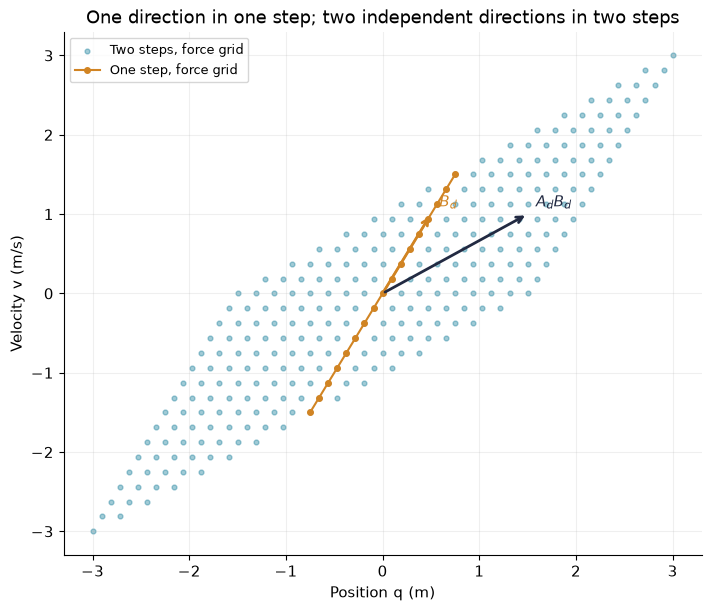

In [8]:
def controllability_matrix(A, B):
    return np.hstack([np.linalg.matrix_power(A, j) @ B for j in range(A.shape[0])])

C_mass = controllability_matrix(A_mass, B_mass)
Cd_mass = controllability_matrix(Ad, Bd)
print("Continuous-time controllability matrix:\n", C_mass)
print("Discrete-time controllability matrix:\n", Cd_mass)
print("Ranks:", np.linalg.matrix_rank(C_mass), np.linalg.matrix_rank(Cd_mass))
assert np.isclose(np.linalg.det(C_mass), -1/mass**2)
assert np.isclose(np.linalg.det(Cd_mass), -h**3/mass**2)

forces = np.linspace(-1.5, 1.5, 17)
one_step = forces[:, None] * Bd[:, 0]
u0_grid, u1_grid = np.meshgrid(forces, forces)
two_steps = (u0_grid.ravel()[:, None] * (Ad @ Bd)[:, 0]
             + u1_grid.ravel()[:, None] * Bd[:, 0])
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
ax.scatter(two_steps[:, 0], two_steps[:, 1], s=12, alpha=.4, color=SLOW,
           label="Two steps, force grid")
ax.plot(one_step[:, 0], one_step[:, 1], "o-", color=FAST, markersize=4,
        label="One step, force grid")
for direction, label, color in [(Bd[:, 0], r"$B_d$", FAST),
                                 ((Ad @ Bd)[:, 0], r"$A_d B_d$", TOTAL)]:
    ax.annotate("", xy=direction, xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": color, "lw": 2})
    ax.annotate(label, xy=direction, xytext=(6, 5), textcoords="offset points", color=color)
ax.set(xlabel="Position q (m)", ylabel="Velocity v (m/s)",
       title="One direction in one step; two independent directions in two steps")
ax.legend(fontsize=9)
plt.show()

The plotted force grid is bounded, so the two-step points fill only a parallelogram. **Controllability is a span statement with unconstrained inputs:** allowing arbitrary real commands extends the two independent directions to the whole plane. It does not promise that every target is reachable with these particular force limits.

### 4.1 Move the mass and bring it to rest

For a two-step transfer,
$$[A_dB_d\ B_d]\begin{bmatrix}u_0\\u_1\end{bmatrix}
=x_f-A_d^2x_0.$$
The columns are in chronological input order. This reverses the columns of $\mathcal C_d$, preserving rank but changing which command belongs to which column.

**Predict:** Starting from rest, what signs should the two force commands have to move right and finish at rest?

Commands [u0, u1]: [ 1. -1.]
States [q, v] at each sample:
 [[0.  0. ]
 [0.5 1. ]
 [1.  0. ]]
Final-state error: 2.220446049250313e-16


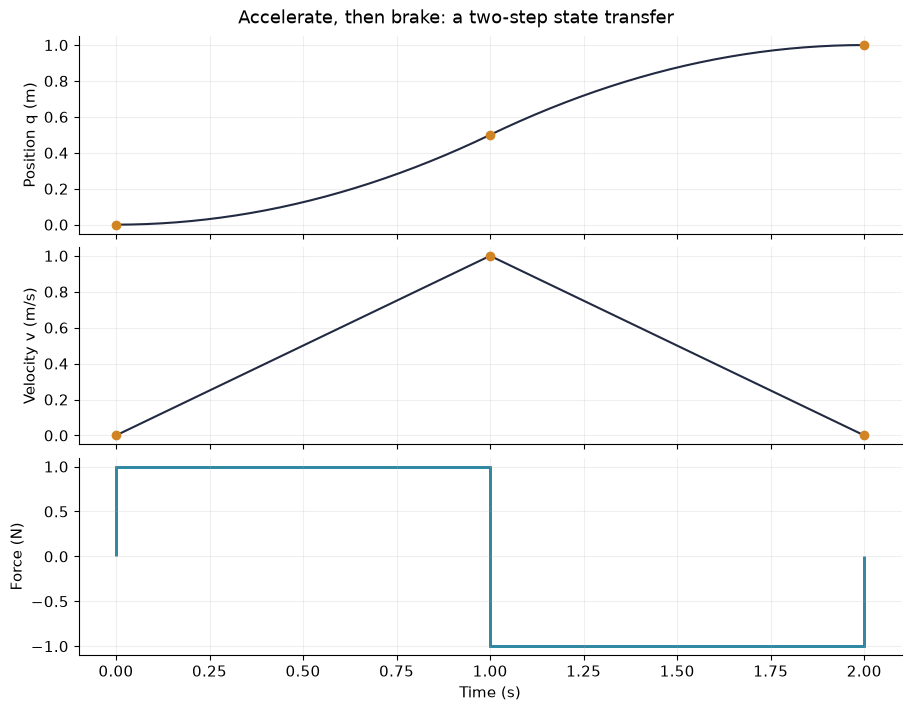

In [9]:
x0_transfer = np.array([0., 0.])
x_target = np.array([1., 0.])
R2 = np.column_stack([(Ad @ Bd)[:, 0], Bd[:, 0]])
commands = np.linalg.solve(R2, x_target - Ad @ Ad @ x0_transfer)
x_transfer = simulate_discrete(Ad, Bd, commands, x0_transfer)
assert np.allclose(x_transfer[-1], x_target)
assert np.allclose(R2, Cd_mass[:, ::-1])
print("Commands [u0, u1]:", commands)
print("States [q, v] at each sample:\n", x_transfer)
print("Final-state error:", np.linalg.norm(x_transfer[-1]-x_target))

# Exact intersample motion for a constant force on each interval.
t_dense, states_dense = [], []
for k, force in enumerate(commands):
    s = np.linspace(0., h, 101)
    qk, vk = x_transfer[k]
    segment = np.column_stack([qk + s*vk + .5*s*s*force/mass,
                               vk + s*force/mass])
    t_dense.extend(k*h+s)
    states_dense.extend(segment)
t_dense, states_dense = np.array(t_dense), np.array(states_dense)
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True, layout="constrained")
for j, label in enumerate(["Position q (m)", "Velocity v (m/s)"]):
    axes[j].plot(t_dense, states_dense[:, j], color=TOTAL)
    axes[j].plot(h*np.arange(3), x_transfer[:, j], "o", color=FAST)
    axes[j].set(ylabel=label)
axes[2].stairs(commands, h*np.arange(3), color=SLOW, linewidth=2)
axes[2].set(xlabel="Time (s)", ylabel="Force (N)")
fig.suptitle("Accelerate, then brake: a two-step state transfer")
plt.show()

### 4.2 A stable system can be uncontrollable

Consider $A=\operatorname{diag}(-1,-2)$ and $B=[1,0]^T$. The second state decays naturally, but the actuator cannot change it. Starting with $x_2=0$, no input produces a nonzero second state.

**Predict:** Can the target $[0,1]^T$ be reached from the origin? Does stability help with this transfer?

In [10]:
A_unreachable = np.diag([-1., -2.])
B_unreachable = np.array([[1.], [0.]])
Ad_unreachable, Bd_unreachable = zoh_discretize(A_unreachable, B_unreachable, h)
Cu = controllability_matrix(Ad_unreachable, Bd_unreachable)
R_unreachable = Cu[:, ::-1]
target_unreachable = np.array([0., 1.])
best_commands, *_ = np.linalg.lstsq(R_unreachable, target_unreachable, rcond=None)
best_final = R_unreachable @ best_commands
print("Continuous-time eigenvalues:", np.linalg.eigvals(A_unreachable))
print("Controllability rank:", np.linalg.matrix_rank(Cu))
print("Target:", target_unreachable, "; closest achievable two-step state:", best_final)
print("Residual (nonzero means no exact transfer):", np.linalg.norm(best_final-target_unreachable))
assert np.linalg.matrix_rank(Cu) == 1
assert np.allclose(best_final, [0., 0.])

Continuous-time eigenvalues: [-1.+0.j -2.+0.j]
Controllability rank: 1
Target: [0. 1.] ; closest achievable two-step state: [0. 0.]
Residual (nonzero means no exact transfer): 1.0


## 5. Observability: can the sensor reveal the initial state?

A system is observable if the **known input history and measured output history** determine its initial state uniquely. We do not need to measure every state directly: dynamics can expose an unmeasured state in later outputs.

For $y_k=C_d x_k+D_d u_k$, subtract the known input contribution:
$$\widetilde y_k=y_k-D_du_k-\sum_{j=0}^{k-1}C_dA_d^{k-1-j}B_du_j
=C_dA_d^k x_0.$$
Then
$$\begin{bmatrix}\widetilde y_0\\\widetilde y_1\\\vdots\\\widetilde y_{n-1}\end{bmatrix}
=\underbrace{\begin{bmatrix}C_d\\C_dA_d\\\vdots\\C_dA_d^{n-1}\end{bmatrix}}_{\mathcal O_d}x_0.$$
Full column rank means a unique initial state.

### 5.1 Compare position and velocity sensors
**Predict:** Which sensor can reveal both initial position and initial velocity?

In [11]:
def observability_matrix(A, C):
    return np.vstack([C @ np.linalg.matrix_power(A, j) for j in range(A.shape[0])])

C_position = np.array([[1., 0.]])
C_velocity = np.array([[0., 1.]])
O_position = observability_matrix(Ad, C_position)
O_velocity = observability_matrix(Ad, C_velocity)
for label, C_sensor in [("Position", C_position), ("Velocity", C_velocity)]:
    O_ct = observability_matrix(A_mass, C_sensor)
    O_dt = observability_matrix(Ad, C_sensor)
    print(f"{label} sensor: continuous rank={np.linalg.matrix_rank(O_ct)}, "
          f"discrete rank={np.linalg.matrix_rank(O_dt)}")
    print("Discrete observability matrix:\n", O_dt)
assert np.isclose(np.linalg.det(O_position), h)
assert np.linalg.matrix_rank(O_velocity) == 1
# Duality: the observability matrix is the transpose of the dual controllability matrix.
assert np.allclose(O_position, controllability_matrix(Ad.T, C_position.T).T)

Position sensor: continuous rank=2, discrete rank=2
Discrete observability matrix:
 [[1. 0.]
 [1. 1.]]
Velocity sensor: continuous rank=1, discrete rank=1
Discrete observability matrix:
 [[0. 1.]
 [0. 1.]]


### 5.2 Recover position and velocity from two position samples

For the mass with $D=0$,
$$y_0=q_0,\qquad y_1=q_0+h v_0+\frac{h^2}{2m}u_0.$$
Therefore,
$$q_0=y_0,\qquad v_0=\frac{y_1-y_0}{h}-\frac{h}{2m}u_0.$$
Use $x_0=[2,3]^T$ to generate synthetic measurements; then reconstruct it using only the measurements, the input, and the model. The known state is used only to check the result.

**Predict:** If the input accelerates the mass, will ignoring its contribution overestimate or underestimate the initial velocity?

In [12]:
x0_unknown = np.array([2., 3.])  # synthetic truth, not given to the reconstruction
force_known = 1.0
states_for_measurement = simulate_discrete(Ad, Bd, [force_known], x0_unknown)
y_position = (states_for_measurement @ C_position.T).ravel()
known_output_contribution = np.array([0., (C_position @ Bd).item()*force_known])
x0_reconstructed = np.linalg.solve(O_position, y_position-known_output_contribution)
x0_ignoring_input = np.linalg.solve(O_position, y_position)
assert np.allclose(x0_reconstructed, x0_unknown)
print("Position samples:", y_position)
print("Reconstructed initial state:", x0_reconstructed)
print("Incorrect result if the known input is ignored:", x0_ignoring_input)
print("Reconstruction error:", np.linalg.norm(x0_reconstructed-x0_unknown))

Position samples: [2.  5.5]
Reconstructed initial state: [2. 3.]
Incorrect result if the known input is ignored: [2.  3.5]
Reconstruction error: 0.0


### 5.3 Indistinguishable initial states with velocity-only sensing

Two states that differ only in position produce identical velocity histories under the same input. The unobserved position offset persists forever.

**Predict:** Will collecting more exact velocity samples reveal this offset?

Largest velocity-output difference: 0.0


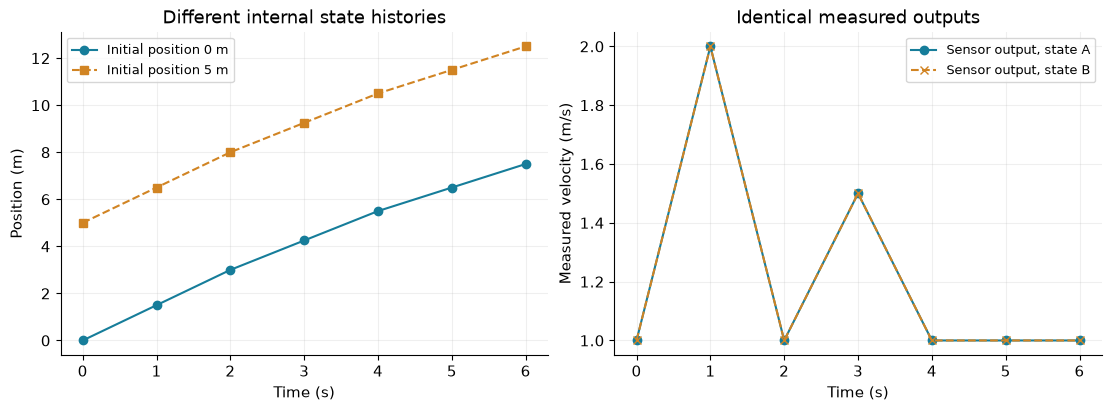

In [13]:
initial_a = np.array([0., 1.])
initial_b = np.array([5., 1.])
inputs_shared = np.array([1., -1., .5, -.5, 0., 0.])
trajectory_a = simulate_discrete(Ad, Bd, inputs_shared, initial_a)
trajectory_b = simulate_discrete(Ad, Bd, inputs_shared, initial_b)
outputs_a = (trajectory_a @ C_velocity.T).ravel()
outputs_b = (trajectory_b @ C_velocity.T).ravel()
assert np.allclose(outputs_a, outputs_b)
assert np.allclose(trajectory_b-trajectory_a, [5., 0.])
print("Largest velocity-output difference:", np.max(np.abs(outputs_b-outputs_a)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
t_shared = h*np.arange(len(trajectory_a))
axes[0].plot(t_shared, trajectory_a[:, 0], "o-", label="Initial position 0 m", color=SLOW)
axes[0].plot(t_shared, trajectory_b[:, 0], "s--", label="Initial position 5 m", color=FAST)
axes[0].set(xlabel="Time (s)", ylabel="Position (m)", title="Different internal state histories")
axes[1].plot(t_shared, outputs_a, "o-", label="Sensor output, state A", color=SLOW)
axes[1].plot(t_shared, outputs_b, "x--", label="Sensor output, state B", color=FAST)
axes[1].set(xlabel="Time (s)", ylabel="Measured velocity (m/s)", title="Identical measured outputs")
for ax in axes: ax.legend(fontsize=9)
plt.show()

## 6. Relating the discrete-time matrices to continuous time

In continuous time, an input's influence evolves as
$$e^{As}B=B+sAB+\frac{s^2}{2}A^2B+\cdots.$$
The directions $B,AB,A^2B,\ldots$ describe direct actuation followed by propagation through the dynamics. This produces the continuous-time controllability matrix.

With zero input,
$$y(t)=Ce^{At}x_0=Cx_0+tCAx_0+\frac{t^2}{2}CA^2x_0+\cdots.$$
The matrices $C,CA,CA^2,\ldots$ describe information in the output, its slope, and its curvature. This produces the continuous-time observability matrix.

For $A_d=e^{Ah}$,
$$\frac{A_dB-B}{h}\to AB,\qquad \frac{CA_d-C}{h}\to CA.$$
These are derivatives of the influence and observation maps, not a claim that $B_d=B$. The exact sampled input matrix is still the integral defining $B_d$.

The following finite-difference experiment uses the damped oscillator to make the approximation error visible. For the free mass, $A^2=0$ makes these particular differences exact. Certain sampling periods can lose controllability or observability in general, so test the actual sampled matrices rather than assuming rank is preserved.

In [14]:
A_bridge = np.array([[0., 1.], [-2., -.6]])
B_bridge = np.array([[0.], [1.]])
C_bridge = np.array([[1., 0.]])
bridge_steps = np.array([1., .3, .1, .03, .01])
print(" h       input-direction error     output-slope error")
for dt in bridge_steps:
    E = expm(dt*A_bridge)
    input_error = np.linalg.norm((E @ B_bridge-B_bridge)/dt-A_bridge @ B_bridge)
    output_error = np.linalg.norm((C_bridge @ E-C_bridge)/dt-C_bridge @ A_bridge)
    print(f"{dt:5.2f}       {input_error:12.5e}         {output_error:12.5e}")

 h       input-direction error     output-slope error
 1.00        6.32217e-01          8.47609e-01
 0.30        2.39249e-01          3.00296e-01
 0.10        8.48150e-02          1.03167e-01
 0.03        2.59709e-02          3.12163e-02
 0.01        8.70673e-03          1.04289e-02


## 7. Optional: observable does not mean insensitive to noise

For two position samples with independent errors $\eta_0,\eta_1$ of standard deviation $\sigma_q$,
$$\widehat v_0-v_0=\frac{\eta_1-\eta_0}{h},\qquad
\operatorname{std}(\widehat v_0-v_0)=\frac{\sqrt2\,\sigma_q}{h}.$$
The two-sample observability matrix has full rank for every $h>0$, but closely spaced samples make this velocity estimate sensitive to noise.

**Predict:** How does halving $h$ change the standard deviation? This experiment always uses exactly two samples; it does not imply that faster sampling is worse when many samples and an appropriate estimator are used.

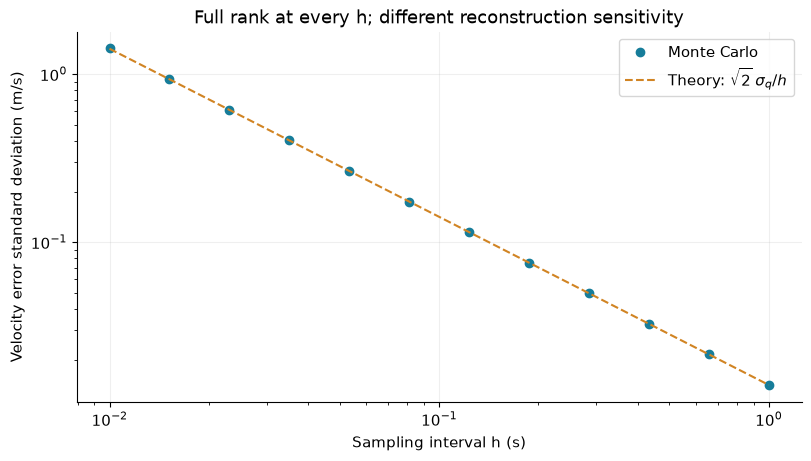

In [15]:
rng = np.random.default_rng(6246)
sigma_q = 0.01  # meters
noise_steps = np.geomspace(.01, 1., 12)
trials = 20000
observed_std, predicted_std, ranks = [], [], []
for dt in noise_steps:
    Ad_noise, Bd_noise = zoh_discretize(A_mass, B_mass, dt)
    O_noise = observability_matrix(Ad_noise, C_position)
    truth_samples = simulate_discrete(Ad_noise, Bd_noise, [force_known], x0_unknown)
    clean_y = (truth_samples @ C_position.T).ravel()
    noisy_y = clean_y + rng.normal(0., sigma_q, size=(trials, 2))
    v_est = (noisy_y[:, 1]-noisy_y[:, 0])/dt-dt*force_known/(2*mass)
    observed_std.append(np.std(v_est-x0_unknown[1], ddof=1))
    predicted_std.append(np.sqrt(2)*sigma_q/dt)
    ranks.append(np.linalg.matrix_rank(O_noise))
assert all(rank == 2 for rank in ranks)
assert np.allclose(observed_std, predicted_std, rtol=.04)
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.loglog(noise_steps, observed_std, "o", color=SLOW, label="Monte Carlo")
ax.loglog(noise_steps, predicted_std, "--", color=FAST, label=r"Theory: $\sqrt{2}\,\sigma_q/h$")
ax.set(xlabel="Sampling interval h (s)", ylabel="Velocity error standard deviation (m/s)",
       title="Full rank at every h; different reconstruction sensitivity")
ax.legend()
plt.show()

## 8. Optional: limits of linearization
The systems $\dot x=-x^3$ and $\dot x=x^3$ both have zero Jacobian at the origin, but the first is asymptotically stable and the second is unstable. Their exact solutions are
$$x_-(t)=\frac{x_0}{\sqrt{1+2x_0^2t}},\qquad
x_+(t)=\frac{x_0}{\sqrt{1-2x_0^2t}}.$$
The unstable solution exists only before $t_{\rm escape}=1/(2x_0^2)$ when $x_0\ne0$. Plot only times below that limit. Imaginary-axis eigenvalues in a nonlinear Jacobian require additional analysis.

This extension has also moved from Week 4. It highlights why the LTI equivalence of asymptotic and exponential stability does not extend to general nonlinear systems.

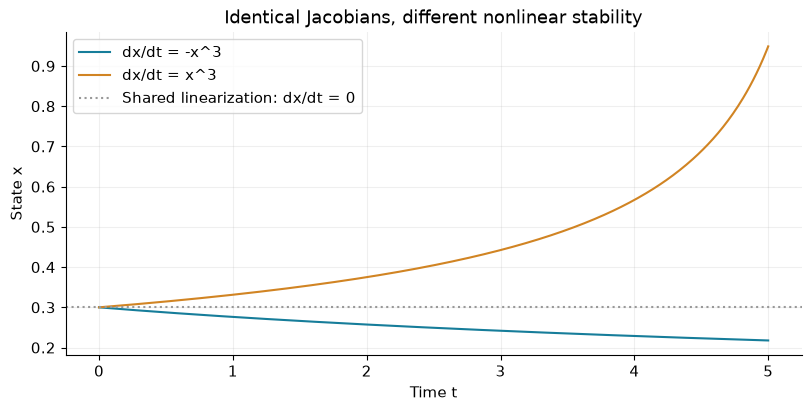

In [16]:
x0_nonlinear = .3  # use a nonzero initial state
t_escape = 1 / (2 * x0_nonlinear**2)
t_nonlinear = np.linspace(0., .9 * t_escape, 401)
x_minus = x0_nonlinear / np.sqrt(1 + 2 * x0_nonlinear**2 * t_nonlinear)
x_plus = x0_nonlinear / np.sqrt(1 - 2 * x0_nonlinear**2 * t_nonlinear)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(t_nonlinear, x_minus, color=SLOW, label="dx/dt = -x^3")
ax.plot(t_nonlinear, x_plus, color=FAST, label="dx/dt = x^3")
ax.axhline(x0_nonlinear, color="0.6", ls=":", label="Shared linearization: dx/dt = 0")
ax.set(xlabel="Time t", ylabel="State x", title="Identical Jacobians, different nonlinear stability")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 9. Student investigations

1. Explain why one convergent saddle trajectory does not prove stability of the equilibrium.
2. Increase the off-diagonal coupling in the non-normal example. Recompute the eigenvector basis if using modal reconstruction. How do the eigenvalues and the transient amplification change?
3. Change the mass and sampling interval. Verify that the exact discrete model continues to match the continuous solution at the samples.
4. In the two-step transfer, double the target position while keeping the final velocity zero. Predict the commands before computing them. Then try a nonzero initial state.
5. Explain why bounded-force points form a parallelogram even though the mass is controllable.
6. Replace the position sensor with the velocity sensor. Identify a nonzero vector in the null space of its observability matrix and interpret it physically.
7. In the reconstruction example, explain the bias caused by ignoring the known input.
8. Compare the finite-difference expressions in Section 6 with the discrete-time matrices. Which limits produce $AB$ and $CA$?
9. Optional: halve the position measurement noise standard deviation. Predict the change in the velocity reconstruction error.

### Suggested answers to the prediction questions

- The stable spiral and the saddle trajectory exactly on its stable line converge. The center does not converge; the perturbed saddle trajectory eventually leaves the neighborhood. One trajectory cannot establish stability.
- A temporary increase in norm is compatible with exponential stability because the bound permits $M>1$.
- During a held force interval, changing velocity changes position; this creates the $h^2u_k/(2m)$ term.
- Euler's multiplier at $h=1.2$ is $-1.4$: it alternates sign and grows. This is a numerical artifact.
- The mass's sampled controllability determinant is $-h^3/m^2\ne0$. Moving right and stopping from rest requires a positive command followed by a negative command. With the defaults they are $[1,-1]$.
- A stable second state that the actuator cannot influence cannot be moved from zero to one.
- A position sensor reveals velocity through changes in position. A velocity-only sensor leaves initial position undetermined, however many exact samples are collected.
- Ignoring a positive known force overestimates initial velocity by $h u_0/(2m)$.
- Halving $h$ doubles the two-sample velocity error standard deviation; halving $\sigma_q$ halves it.

### Takeaways

Stability concerns unforced dynamics, controllability concerns actuator influence, and observability concerns sensor information. Exact sampling connects the continuous plant to a digital controller. Matrix ranks describe structural possibilities; constraints, noise, and conditioning determine practical performance.

### Source material

The stability and nonlinear examples were relocated from the Fall 2026 Week 4 notebook. Sampling and the force-driven mass follow the October 28, 2015 legacy lecture notes (PDF pages 1, 2, and 5); observability, the position/velocity sensor comparison, and duality follow the November 4, 2015 notes (PDF pages 1-2). The numerical transfer, reconstruction, finite-difference, and noise experiments develop those examples for the Week 5 course note.

Gramians, minimum-energy control, PBH tests, and feedback design are reserved for later notebooks.